# Dataset Audit & Quality Assessment

Project:
Explainable AI-Powered Pneumonia Diagnosis & Clinical Decision Support System

Objectives:
- Verify dataset integrity
- Analyze class distribution
- Detect corrupted images
- Analyze image dimensions
- Identify duplicate images
- Detect blurry images
- Generate a dataset quality report

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import hashlib
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
import os

DATASET_PATH = "/content/drive/MyDrive/archive (6)/chest_xray/chest_xray"

for split in ["train","val","test"]:

    print(f"\n{split.upper()}")

    split_path = os.path.join(DATASET_PATH, split)

    for cls in os.listdir(split_path):

        if cls.startswith("."):
            continue

        cls_path = os.path.join(split_path, cls)

        print(cls, len(os.listdir(cls_path)))


TRAIN
NORMAL 1355
PNEUMONIA 3889

VAL
PNEUMONIA 9
NORMAL 9

TEST
PNEUMONIA 390
NORMAL 234


Dataset Audit Findings

- Total Images: 5,886
- Normal Cases: 1,598
- Pneumonia Cases: 4,288
- Significant class imbalance observed (~1:2.68)
- Validation set contains only 18 images and is insufficient for robust model selection

In [14]:
image_counts = {
    "Train Normal": 1355,
    "Train Pneumonia": 3889,
    "Val Normal": 9,
    "Val Pneumonia": 9,
    "Test Normal": 234,
    "Test Pneumonia": 390
}

import pandas as pd

counts_df = pd.DataFrame(
    image_counts.items(),
    columns=["Class", "Count"]
)

counts_df

,Class,Count
0,Train Normal,1355
1,Train Pneumonia,3889
2,Val Normal,9
3,Val Pneumonia,9
4,Test Normal,234
5,Test Pneumonia,390


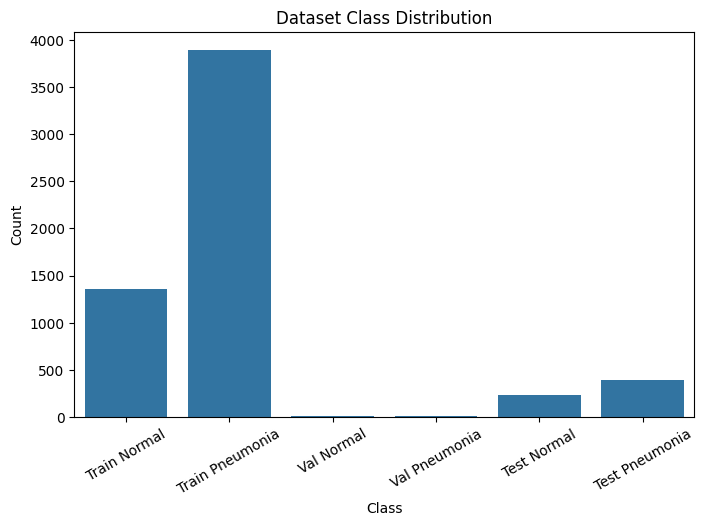

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=counts_df,
    x="Class",
    y="Count"
)

plt.title("Dataset Class Distribution")
plt.xticks(rotation=30)

plt.show()

In [16]:
normal_total = 1355 + 9 + 234
pneumonia_total = 3889 + 9 + 390

ratio = pneumonia_total / normal_total

print("Normal Images:", normal_total)
print("Pneumonia Images:", pneumonia_total)
print("Imbalance Ratio:", round(ratio,2))

Normal Images: 1598
Pneumonia Images: 4288
Imbalance Ratio: 2.68


## Observation

The dataset is imbalanced.

Normal Images : 1,598

Pneumonia Images : 4,288

Imbalance Ratio : 1 : 2.68

Potential Mitigation Strategies:

- Class Weights
- Data Augmentation
- Stratified Splitting

In [19]:
overall_df = pd.DataFrame({
    "Class":["NORMAL","PNEUMONIA"],
    "Count":[1598,4288]
})

overall_df


,Class,Count
0,NORMAL,1598
1,PNEUMONIA,4288


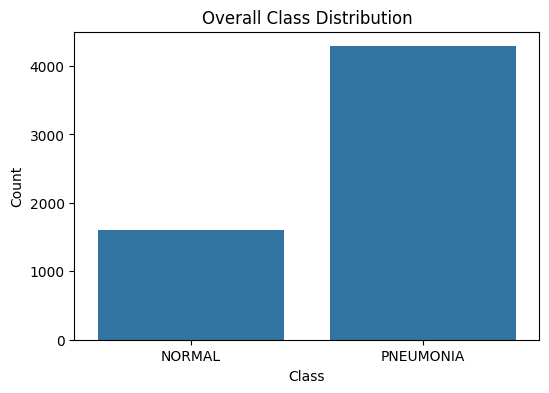

In [20]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=overall_df,
    x="Class",
    y="Count"
)

plt.title("Overall Class Distribution")

plt.show()

# Image Dimension Analysis

Objective:
- Analyze image resolutions
- Identify dimension variability
- Determine suitable input size for deep learning models

In [21]:
import os
from PIL import Image

widths = []
heights = []

In [22]:
for split in ["train","val","test"]:

    split_path = os.path.join(DATASET_PATH, split)

    for cls in os.listdir(split_path):

        if cls.startswith("."):
            continue

        cls_path = os.path.join(split_path, cls)

        for img_name in os.listdir(cls_path):

            if not img_name.lower().endswith(
                (".jpg",".jpeg",".png")
            ):
                continue

            img_path = os.path.join(
                cls_path,
                img_name
            )

            try:

                img = Image.open(img_path)

                w, h = img.size

                widths.append(w)
                heights.append(h)

            except:
                pass

In [23]:
print("Total Images Analysed:", len(widths))

print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))

print("Minimum Height:", min(heights))
print("Maximum Height:", max(heights))

print("Average Width :", round(sum(widths)/len(widths),2))
print("Average Height:", round(sum(heights)/len(heights),2))

Total Images Analysed: 5882
Minimum Width : 384
Maximum Width : 2916
Minimum Height: 127
Maximum Height: 2713
Average Width : 1327.43
Average Height: 970.48


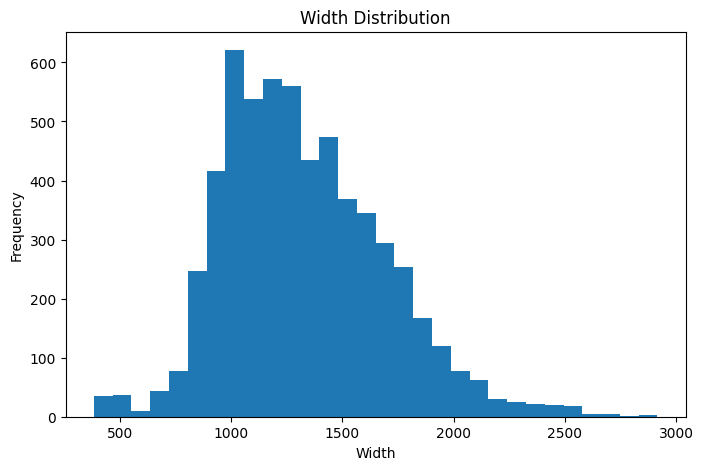

In [24]:
plt.figure(figsize=(8,5))

plt.hist(widths,bins=30)

plt.title("Width Distribution")

plt.xlabel("Width")
plt.ylabel("Frequency")

plt.show()

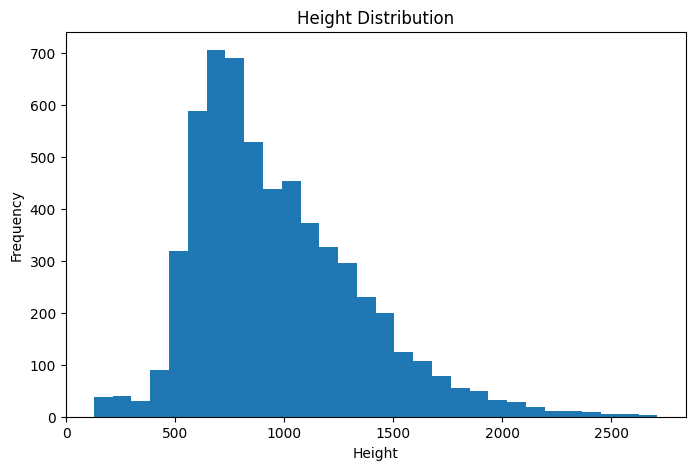

In [25]:
plt.figure(figsize=(8,5))

plt.hist(heights,bins=30)

plt.title("Height Distribution")

plt.xlabel("Height")
plt.ylabel("Frequency")

plt.show()

## Resolution Analysis Findings

- Image resolutions vary significantly across the dataset.
- Width range: 384–2916 pixels.
- Height range: 127–2713 pixels.
- Average resolution: 1327 × 970 pixels.

Conclusion:

The dataset is not standardized and requires resizing before model training.

A target input size of 224 × 224 will be used for transfer learning models such as MobileNetV2, ResNet50, and EfficientNetB0.

In [26]:
from PIL import Image

corrupted_files = []
total_files = 0

In [27]:
for split in ["train","val","test"]:

    split_path = os.path.join(DATASET_PATH, split)

    for cls in os.listdir(split_path):

        if cls.startswith("."):
            continue

        cls_path = os.path.join(split_path, cls)

        for img_name in os.listdir(cls_path):

            if not img_name.lower().endswith(
                (".jpg",".jpeg",".png")
            ):
                continue

            total_files += 1

            img_path = os.path.join(
                cls_path,
                img_name
            )

            try:

                img = Image.open(img_path)
                img.verify()

            except:

                corrupted_files.append(img_path)

In [28]:
print("Total Images Checked:", total_files)

print("Corrupted Images Found:",
      len(corrupted_files))

Total Images Checked: 5882
Corrupted Images Found: 0


In [29]:
corrupted_files[:20]

[]

## Corrupted File Analysis

Results:

- Total Valid Image Files Checked: 5,882
- Corrupted Images Detected: 0

Conclusion:

The dataset passed integrity validation with no corrupted image files identified.

The discrepancy between total file count and valid image count is attributed to metadata/system files (e.g., .DS_Store), which were excluded from analysis.

# Duplicate Image Detection

Objective:

- Identify identical image files
- Detect repeated samples
- Evaluate dataset quality

In [30]:
import hashlib

hash_dict = {}
duplicate_files = []

In [31]:
for split in ["train", "val", "test"]:

    split_path = os.path.join(DATASET_PATH, split)

    for cls in os.listdir(split_path):

        if cls.startswith("."):
            continue

        cls_path = os.path.join(split_path, cls)

        for img_name in os.listdir(cls_path):

            if not img_name.lower().endswith(
                (".jpg",".jpeg",".png")
            ):
                continue

            img_path = os.path.join(
                cls_path,
                img_name
            )

            try:

                with open(img_path, "rb") as f:

                    file_hash = hashlib.md5(
                        f.read()
                    ).hexdigest()

                if file_hash in hash_dict:

                    duplicate_files.append(
                        (img_path,
                         hash_dict[file_hash])
                    )

                else:

                    hash_dict[file_hash] = img_path

            except:
                pass

In [32]:
print(
    "Duplicate Images Found:",
    len(duplicate_files)
)

Duplicate Images Found: 58


In [33]:
duplicate_files[:10]

[('/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/IM-0542-0001.jpeg',
  '/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/IM-0542-0001 (1).jpeg'),
 ('/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/NORMAL2-IM-0587-0001-0002.jpeg',
  '/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/NORMAL2-IM-0587-0001-0001.jpeg'),
 ('/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/NORMAL2-IM-1400-0001.jpeg',
  '/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/NORMAL2-IM-1400-0001 (1).jpeg'),
 ('/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/NORMAL2-IM-1419-0001.jpeg',
  '/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/NORMAL2-IM-1419-0001 (1).jpeg'),
 ('/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/NORMAL2-IM-1422-0001.jpeg',
  '/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/NORMAL2-

## Duplicate Image Analysis

Results:

- Total Duplicate Images Found: 58
- Duplicate Rate: ~1%

Observations:

Most duplicates appear to be replicated files generated during dataset packaging and extraction.

Examples:

- IM-0542-0001.jpeg
- IM-0542-0001 (1).jpeg

Impact:

Duplicate images may introduce slight data redundancy and bias model evaluation.

Decision:

Duplicates will be documented but retained to preserve the original dataset.

# Blur Detection

Objective:

- Detect low-quality X-ray images
- Identify potentially blurry samples
- Assess dataset quality

In [34]:
blur_scores = []
blurry_images = []

In [35]:
import cv2
from tqdm import tqdm

for split in ["train","val","test"]:

    split_path = os.path.join(DATASET_PATH, split)

    for cls in os.listdir(split_path):

        if cls.startswith("."):
            continue

        cls_path = os.path.join(split_path, cls)

        for img_name in tqdm(os.listdir(cls_path)):

            if not img_name.lower().endswith(
                (".jpg",".jpeg",".png")
            ):
                continue

            img_path = os.path.join(
                cls_path,
                img_name
            )

            try:

                image = cv2.imread(
                    img_path,
                    cv2.IMREAD_GRAYSCALE
                )

                score = cv2.Laplacian(
                    image,
                    cv2.CV_64F
                ).var()

                blur_scores.append(score)

                if score < 100:

                    blurry_images.append(
                        (img_path, score)
                    )

            except:
                pass

100%|██████████| 234/234 [00:09<00:00, 25.32it/s]


In [36]:
print(
    "Potentially Blurry Images:",
    len(blurry_images)
)

Potentially Blurry Images: 1941


In [37]:
blurry_images[:10]

[('/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/IM-0533-0001-0001.jpeg',
  np.float64(94.46845257304184)),
 ('/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/IM-0545-0001-0001.jpeg',
  np.float64(84.46663350513131)),
 ('/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/IM-0541-0001.jpeg',
  np.float64(94.62401242186007)),
 ('/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/IM-0531-0001-0001.jpeg',
  np.float64(98.47124064870583)),
 ('/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/IM-0521-0001.jpeg',
  np.float64(83.05461841178774)),
 ('/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/IM-0523-0001-0002.jpeg',
  np.float64(93.0847662346268)),
 ('/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/IM-0539-0001-0001.jpeg',
  np.float64(97.47699966914055)),
 ('/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/train/NORMAL/IM-0526-0001.j

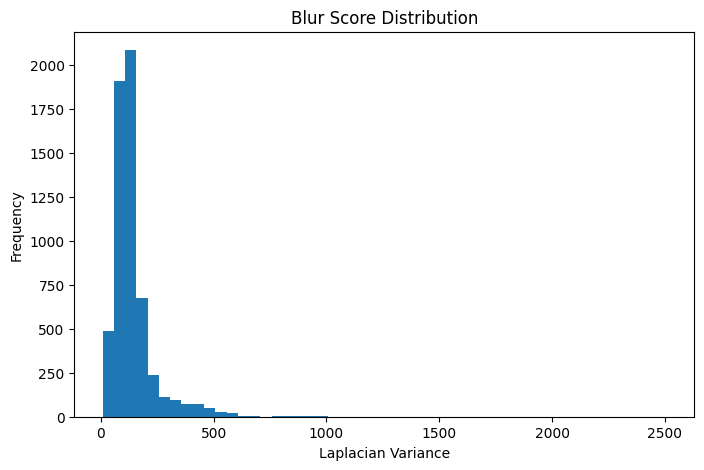

In [38]:
plt.figure(figsize=(8,5))

plt.hist(
    blur_scores,
    bins=50
)

plt.title(
    "Blur Score Distribution"
)

plt.xlabel(
    "Laplacian Variance"
)

plt.ylabel(
    "Frequency"
)

plt.show()


In [39]:
import numpy as np

print("Minimum:", np.min(blur_scores))
print("Maximum:", np.max(blur_scores))

print("25th Percentile:", np.percentile(blur_scores,25))
print("50th Percentile:", np.percentile(blur_scores,50))
print("75th Percentile:", np.percentile(blur_scores,75))
print("90th Percentile:", np.percentile(blur_scores,90))

Minimum: 8.124156021768865
Maximum: 2505.9830384109405
25th Percentile: 90.47422012514349
50th Percentile: 118.18149622439995
75th Percentile: 155.5287921796009
90th Percentile: 233.87669267337805


In [40]:
quality_levels = []

for score in blur_scores:

    if score < 50:
        quality_levels.append("Low")

    elif score < 100:
        quality_levels.append("Medium")

    else:
        quality_levels.append("High")

In [41]:
from collections import Counter

Counter(quality_levels)

Counter({'High': 3941, 'Medium': 1563, 'Low': 378})

## Image Quality Assessment

### Objective

To evaluate image sharpness and identify potential low-quality X-ray scans that may impact model performance.

### Methodology

Image quality was assessed using the **Variance of Laplacian** technique.

A higher Laplacian variance indicates a sharper image, while lower values suggest reduced image detail and potential blur.

### Blur Score Statistics

| Metric | Value |
|----------|----------|
| Minimum Score | 8.12 |
| Maximum Score | 2505.98 |
| 25th Percentile | 90.47 |
| Median (50th Percentile) | 118.18 |
| 75th Percentile | 155.53 |
| 90th Percentile | 233.88 |

### Image Quality Distribution

| Quality Level | Count |
|--------------|-------|
| High Quality | 3941 |
| Medium Quality | 1563 |
| Low Quality | 378 |

### Observations

- Most images exhibit acceptable to high image quality.
- A smaller subset of images shows reduced sharpness.
- Significant variation in image quality exists across the dataset.
- The majority of images fall above the median blur score threshold.

### Decision

No images were removed based solely on blur scores.

Since this is a publicly accepted benchmark dataset, image quality metrics will be retained for:

- Error Analysis
- Model Performance Investigation
- Explainability Studies

### Conclusion

Image quality variability is present within the dataset and may contribute to future model misclassifications. Blur analysis results will be referenced during the model evaluation and error analysis stages.